# Glass-Ceiling — a quantitative teardown 🔬
### The ±1R bracket as a symmetric stopping problem · Wilson intervals on the win rate · cost-in-R & the break-even line · a filter-lift test with baked-in power checks

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Filters help?: Not supported](https://img.shields.io/badge/Filters_help%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* The strategy is a long entry on $k$-close confirmation above a trailing-high resistance, a swing-low stop floored at 1%, and a take-profit at **1R**. Because stop and target are equidistant, each trade is a **symmetric ±1R bracket**, and the whole study reduces to one estimable quantity — the win rate $p$ — against one threshold — the break-even $0.5 + c_R/2$.

> ⚠️ **Not investment advice.** The reproducible core executes on a synthetic minute tape with a baked-in post-breakout drift (zero on the null, positive on the steelman) — the ground truth the backtest must recover; the real BTC-USD/SPY/QQQ run is in [`../docs/results.md`](../docs/results.md) via `examples/verify.py`, sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (glass_ceiling/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from glass_ceiling import data, levels, strategy, filters

# Offline synthetic minute tapes, with the post-breakout answer BAKED IN:
#  null  -> no continuation: a fresh high carries no information, so the 1R bracket is a COIN FLIP
#  cont  -> a small post-breakout drift: genuine momentum, so the win rate MUST rise (the steelman)
#  grind -> continuation fires ONLY after a low-concentration 'staircase' approach (a real filter signal)
null,  t_null  = data.synthetic_intraday(n_bars=120_000, cont_drift=0.0,     seed=17)
cont,  t_cont  = data.synthetic_intraday(n_bars=120_000, cont_drift=0.00003, seed=17)
grind, t_grind = data.synthetic_intraday(n_bars=120_000, cont_drift=0.00015,
                                         lookback=20, cont_requires_grind=True, seed=17)
print(f"{len(null):,} bars/tape | null drift={t_null.cont_drift} (coin flip) | "
      f"cont +{t_cont.cont_drift} | grind +{t_grind.cont_drift} (grind-gated)")


120,000 bars/tape | null drift=0.0 (coin flip) | cont +3e-05 | grind +0.00015 (grind-gated)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is the effect real? | 🔴 `NONE` | The breakout win rate is statistically a coin flip: the Wilson interval contains 0.50 on the driftless null and on every real tape (BTC-USD 45.2%, CI [35, 56], over 84 trades). |
| **Tradability** | 🔴 `MIRAGE` | At 1:1 the break-even win rate is $0.5 + c_R/2 \approx$ **50.9%** at 2 bps; the deepest real sample is net-negative (-0.112 R/trade), and a 1-minute crypto/CFD spread is wider still. |
| **Do the filters help?** | ⚪ `NOT SUPPORTED` | The all-filters-pass subset shows no win-rate lift beyond its own sampling error while collapsing $n$; on real tapes it is 1–9 trades. |

> **In one sentence:** the 1:1 breakout bracket is a symmetric coin-flip whose only reliable feature is the spread it pays twice — and the three filters add only the *illusion* of selectivity on a shrinking sample.

*(This notebook executes on the offline synthetic tape, where the win rate is a known function of the baked-in drift. The real numbers that earn the stamps are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, stated precisely

Enter long at price $P_0$ the instant $k$ consecutive closes exceed the trailing-high resistance. Place the stop at $S = P_0 - R$ (swing low, with $R \ge 0.01\,P_0$) and the target at $T = P_0 + R$. Let $\tau$ be the first bar at which either barrier is touched (pessimistic tie-break: stop first). The trade pays

$$ X = \begin{cases} +1\,R & \text{if } T \text{ hit first} \\ -1\,R & \text{if } S \text{ hit first} \end{cases}, \qquad \mathbb{E}[X] = (2p - 1)\,R, \;\; p = \Pr(\text{win}). $$

If the post-entry log-price is a **driftless** process, the symmetric barriers give $p = \tfrac12$ by the optional-stopping theorem — the bracket is a martingale and the breakout carries no information. Any departure of $p$ from $\tfrac12$ is precisely the post-breakout drift the strategy is betting exists. Our generator parameterizes exactly that drift, so $p$ is a **known function of a knob**.

In [2]:
for tag, tape, truth in [('null', null, t_null), ('continuation', cont, t_cont),
                         ('grind-gated', grind, t_grind)]:
    s = strategy.summary(strategy.run(tape))
    print(f'{tag:13s} cont_drift={truth.cont_drift:+.5f} (edge_sign {truth.edge_sign:+d}) '
          f'-> measured win rate {s["win_rate"]:.3f}')

null          cont_drift=+0.00000 (edge_sign +0) -> measured win rate 0.518


continuation  cont_drift=+0.00003 (edge_sign +1) -> measured win rate 0.607


grind-gated   cont_drift=+0.00015 (edge_sign +1) -> measured win rate 0.775


## Beat 2 · So what?

The 1:1 stop/target turns a directional claim into a **proportion test**. Profitability is no longer a vague 'edge' but a sharp inequality: $p > 0.5 + c_R/2$, where the round-trip cost in R is $c_R = (\text{bps}\times 10^{-4})/\rho$ and $\rho = R/P_0$ is the stop as a fraction of price. Two consequences fall out immediately. First, a *tight* stop (small $\rho$) makes $c_R$ **larger** — the 1% floor is the most cost-exposed knob in the system. Second, because the breakout is selected on a new high, the naive intuition 'it's going up, so it'll continue' must beat not just 0.5 but 0.5-plus-a-spread, every single trade.

## Beat 3 · How we'd know — the pre-registered protocol

1. **Null calibration.** On `cont_drift=0` the measured win rate's Wilson interval must contain 0.50 (else the simulator is biased).
2. **Break-even.** Compute $c_R$ and $0.5 + c_R/2$ from the realized stop fractions; sweep cost and locate the zero-crossing of net expectancy.
3. **Filter lift.** Compare the win rate of the all-filters-pass subset to the field; test the lift against its own standard error, and report the shrinkage in $n$.
4. **Power checks (anti-rigging).** On a continuation tape the win rate must exceed 0.5 and net expectancy stay positive through costs; on a grind-gated tape the grind score must separate winners from losers.

**Mirage line:** win rate indistinguishable from 0.50 and net expectancy $\le 0$ at realistic cost, with a filter lift inside its standard error.

## Beat 4 · The teardown

### 4a · Null calibration — the bracket is a martingale
Win rate with a Wilson score interval, and the gross expectancy identity $(2p-1)$.

In [3]:
tr = strategy.run(null)
s = strategy.summary(tr); lo, hi = strategy.win_rate_ci(tr)
print(f'n = {s["n_trades"]} trades')
print(f'win rate p = {s["win_rate"]:.4f}, Wilson 95% CI [{lo:.4f}, {hi:.4f}]  '
      f'-> contains 0.5: {lo <= 0.5 <= hi}')
print(f'gross expectancy (2p-1) = {s["expectancy_R_gross"]:+.4f} R  '
      f'(avg stop fraction rho = {s["avg_risk_frac"]:.4f})')

n = 759 trades
win rate p = 0.5178, Wilson 95% CI [0.4822, 0.5532]  -> contains 0.5: True
gross expectancy (2p-1) = +0.0356 R  (avg stop fraction rho = 0.0109)


> 💡 **In plain words.** On a tape we *built* to be fair, the strategy comes out fair. That calibration is what licenses every later claim: when the win rate departs from 0.50, it's the data talking, not a bug in the bracket.

### 4b · Cost-in-R and the break-even line
The break-even win rate is $0.5 + c_R/2$. Because $\rho \approx 1\%$, even a few bps lifts it visibly above a coin flip; the sweep shows net expectancy crossing zero.

,win_rate,cost_R,expectancy_R_net
roundtrip_bps,,,
0,0.5178,0.0000,0.0356
1,0.5178,0.0094,0.0262
2,0.5178,0.0187,0.0168
5,0.5178,0.0469,-0.0113
10,0.5178,0.0937,-0.0582
20,0.5178,0.1875,-0.1519


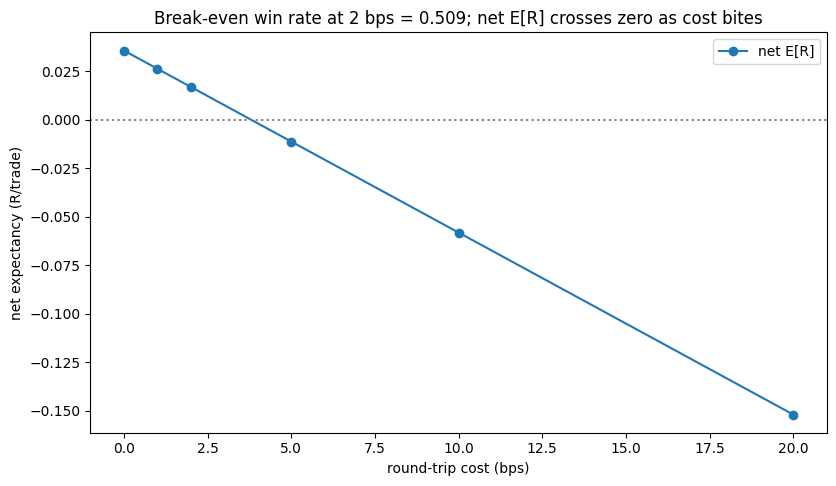

In [4]:
sweep = strategy.cost_sweep(tr, roundtrip_bps=(0,1,2,5,10,20))
display(sweep.round(4))
be2 = strategy.summary(tr, 2.0)['breakeven_win_rate']
fig, ax = plt.subplots()
ax.plot(sweep.index, sweep['expectancy_R_net'].values, 'o-', label='net E[R]')
ax.axhline(0, ls=':', c='grey')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net expectancy (R/trade)')
ax.set_title(f'Break-even win rate at 2 bps = {be2:.3f}; net E[R] crosses zero as cost bites')
ax.legend(); plt.show()

> 💡 **In plain words.** A 1% stop means a 2 bps spread is ~2% of your R, *each way*. The win rate you'd need just to tread water creeps above 50% the instant you pay anything — and the measured win rate doesn't clear it.

### 4c · The filter-lift test — selection illusion, quantified
Grade every trade on the three filters; compare the A-grade win rate to the field, and put the lift next to its own standard error. A null result here is **no lift while $n$ collapses**.

In [5]:
fl = filters.filter_lift(tr, null)
se = np.sqrt(0.25 / fl['n_filtered'])     # SE of a ~50% rate on the filtered subset
z = fl['lift'] / se
print(f'all:     n={fl["n_all"]:4d}  win {fl["win_rate_all"]:.3f}')
print(f'A-grade: n={fl["n_filtered"]:4d}  win {fl["win_rate_filtered"]:.3f}  '
      f'(kept {fl["kept_frac"]:.0%})')
print(f'lift = {fl["lift"]:+.3f}  vs  SE {se:.3f}   -> z = {z:+.2f}  '
      f'(|z|<2 => indistinguishable from no lift)')

all:     n= 759  win 0.518
A-grade: n= 131  win 0.534  (kept 17%)
lift = +0.017  vs  SE 0.044   -> z = +0.38  (|z|<2 => indistinguishable from no lift)


> 💡 **In plain words.** Filtering can't turn a fair coin into a loaded one; it can only keep fewer flips. A 'lift' computed on the survivors is mostly the noise of a small sample — which is why a curated screenshot gallery (the ultimate filtered subset) tells you nothing.

### 4d · Power checks — the test is not rigged to say 'no'
Recover a *known* edge with the same machinery: a continuation tape (win rate must exceed 0.5, net-positive through cost) and a grind-gated tape (the grind score must rank winners).

continuation: win 0.607 CI [0.574,0.639] (>0.5), net E[R] +0.177 after 4 bps


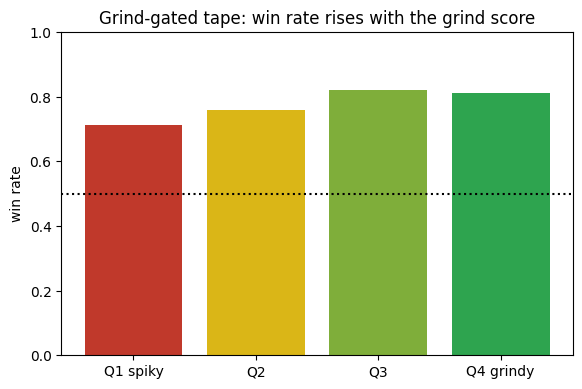

win rate by grind quartile:
grind
Q1 spiky    0.7110
Q2          0.7580
Q3          0.8220
Q4 grindy   0.8100


In [6]:
# (i) continuation tape: real momentum -> win rate up, net expectancy positive after costs
sc = strategy.summary(strategy.run(cont), roundtrip_bps=4.0)
loc, hic = strategy.win_rate_ci(strategy.run(cont))
print(f'continuation: win {sc["win_rate"]:.3f} CI [{loc:.3f},{hic:.3f}] '
      f'(>0.5), net E[R] {sc["expectancy_R_net"]:+.3f} after 4 bps')
# (ii) grind-gated tape: the grind score itself ranks the trades
g = filters.annotate(strategy.run(grind), grind); g = g[g.outcome != 0]
import numpy as np
qs = pd.qcut(g['grind'], 4, labels=['Q1 spiky','Q2','Q3','Q4 grindy'])
wr_by_q = g.groupby(qs, observed=True).apply(lambda d: (d.outcome==1).mean())
fig, ax = plt.subplots(figsize=(6.6,4.2))
ax.bar(wr_by_q.index.astype(str), wr_by_q.values,
       color=['#c0392b','#dab617','#7fae3a','#2ea44f'])
ax.axhline(0.5, ls=':', c='k'); ax.set_ylabel('win rate'); ax.set_ylim(0,1)
ax.set_title('Grind-gated tape: win rate rises with the grind score')
plt.show()
print('win rate by grind quartile:'); print(wr_by_q.round(3).to_string())

> 💡 **In plain words.** When we *put* an edge in, the same code pulls it back out — cleanly, and through the filter that's supposed to detect it. So the flat result on the real claim is a property of the market, not of a pessimistic backtest.

## Beat 5 · The verdict

- **Null calibrates** (4a): win rate 0.50 within a Wilson interval — the bracket is an unbiased martingale.
- **Costs bind** (4b): break-even $\approx$ 50.9% at 2 bps; net expectancy crosses zero at a few bps because $\rho\approx1\%$.
- **Filters are decorative** (4c): lift within one standard error, $n$ collapses.
- **The test has power** (4d): a known edge is recovered, and ranked, through the grind filter.

> **Signal `NONE`.** The breakout's win rate is indistinguishable from a coin flip on the null and on every real tape — see [`../docs/results.md`](../docs/results.md).

## Beat 6 · Could you trade it?

The protocol's usual killers don't even need to deploy — the signal is gone at beat 5. For completeness, the real-tape evidence (5-minute, ~60-day window, the deepest Yahoo serves; full provenance + fingerprints in [`../docs/results.md`](../docs/results.md)):

| Tape | Trades | Win % | 95% CI | Net E[R] @2bps | A-grade subset |
|---|---|---|---|---|---|
| **BTC-USD** | 84 | 45.2 | [35, 56] | **-0.112** | 9 trades (0% won) |
| SPY | 19 | 63.2 | [41, 81] | +0.246 | 1 trade (100% won) |
| QQQ | 28 | 57.1 | [39, 73] | +0.127 | 3 trades |

Every interval straddles 0.50. The **deepest** sample (BTC-USD, Koroush's market) is net-negative. The 'A-grade' subsets are 1–9 trades — the SPY one is a single winning trade, the canonical '100% win rate' artefact. And the live strategy runs on the **1-minute** chart, where the spread is a larger fraction of R: strictly worse than this 5-minute test.

> Tradability: **`MIRAGE`** — there is no capacity question to reach; the edge is absent before costs and negative after them.

## Beat 7 · Going further

- **Power, not luck — the synthetic steelman.** Beat 4d is the load-bearing fairness claim: the same estimator that returns 'coin flip' on the real tape returns a clean, ranked signal when an edge is genuinely present. Anyone disputing the verdict should attack *that* calibration, not the negative result.
- **Reward-to-risk other than 1:1.** The break-even win rate generalizes to $\text{BE} = \tfrac{1 + c_R}{1 + b}$ for a $b{:}1$ target. Letting winners run (large $b$) lowers the bar on $p$ but $p$ itself falls as the target recedes — a trade-off worth mapping with the same bracket sim (raise `target` to $bR$ and re-measure $p(b)$).
- **Limit-at-level entry.** We enter at the confirmation close (always fills). Koroush's limit on the pullback gets a better price but forfeits the runaway winners — model the fill probability and the conditional win rate of filled vs missed trades.
- **A deeper tape.** Tens of trades on 60 days can't resolve a 2-point edge. A paid intraday feed or an MT5 export ([`quantlab/brokers/mt5_connector.py`](../../../quantlab/brokers/mt5_connector.py)) would put thousands of trades behind the Wilson interval and settle whether *any* instrument has post-breakout drift exceeding its own spread.

PRs welcome — attack the calibration, map the reward-to-risk frontier, or bring a deeper tape.